## Sumário

* [Packages & Frameworks](#packages--frameworks)
* [Enunciado do Item a)](#item-a)
    * [Leitura dos Dados](#a-data-preprocessing)
    * [Modelo & Treinamento](#a-model--training)
    * [Métricas de Treinamento](#a-training-metrics)
    * [Predição](#a-prediction)
* [Enunciado do Item b)](#item-b)
    * [Processamento dos Dados](#b-data-preprocessing)
    * [Modelo & Treinamento](#b-model--training)
    * [Métricas de Treinamento](#b-training-metrics)
    * [Predição](#b-prediction)

### Packages & Frameworks

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

### Questão 4

### Item a)

Implemente e treine um autoencoder utilizando o dataset Fashion-MNIST, disponível em: https://www.kaggle.com/datasets/zalando-research/fashionmnist.

O  objetivo deste exercício é compreender como esse tipo de rede neural é capaz de aprender representações comprimidas de dados e realizar reconstruções a partir dessas representações.

O autoencoder pode ser construído utilizando apenas camadas densas (fully connected) ou, alternativamente, camadas convolucionais e deconvolucionais.

Após o treinamento, selecione 10 imagens do conjunto de teste e utilize o modelo treinado para gerar as reconstruções correspondentes. 

Apresente os resultados visualmente, exibindo lado a lado as imagens originais e suas respectivas reconstruções, de modo que seja possível avaliar qualitativamente o desempenho do autoencoder. Apresente também a curva do erro médio ao longo do treinamento.

### a) Data Reading & Preprocessing

In [14]:
(x_train, _), (x_test_full, _) = fashion_mnist.load_data()

# Normalizes Data
x_train = x_train.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

# Flattens Images for a Dense Autoencoder (2D to 1D)
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_full_flat = x_test_full.reshape(
    (len(x_test_full), np.prod(x_test_full.shape[1:]))
)

# Splitting Test Data
x_val_flat, x_test_flat = train_test_split(
    x_test_full_flat, test_size=0.5, random_state=42
)

### a) Model & Training

In [15]:
# Dimension of the Compressed Representation
encoding_dim = 32

# Input Layer
input_ = keras.layers.Input(shape=(784,))

# Encoder
encoded = keras.layers.Dense(128, activation="relu")(input_)
encoded = keras.layers.Dense(64, activation="relu")(encoded)
encoded = keras.layers.Dense(encoding_dim, activation="relu")(
    encoded
)

# Decoder
decoded = keras.layers.Dense(64, activation="relu")(encoded)
decoded = keras.layers.Dense(128, activation="relu")(decoded)
decoded = keras.layers.Dense(784, activation="sigmoid")(decoded)

# Full Model (Autoencoder)
autoencoder = keras.Model(input_, decoded)
autoencoder.compile(optimizer="adam", loss="mean_squared_error")
autoencoder.summary()

# Train the Model
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(x_val_flat, x_val_flat),
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0478 - val_loss: 0.0248
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0227 - val_loss: 0.0212
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0199 - val_loss: 0.0193
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0184 - val_loss: 0.0178
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0174 - val_loss: 0.0171
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0166 - val_loss: 0.0162
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0160 - val_loss: 0.0156
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0154 - val_loss: 0.0153
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0150 - val_loss: 0.0148
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0146 - val_loss: 0.0145
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0142 - val_loss: 0.0141
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━━

### a) Training Metrics

<Figure size 640x480 with 0 Axes>

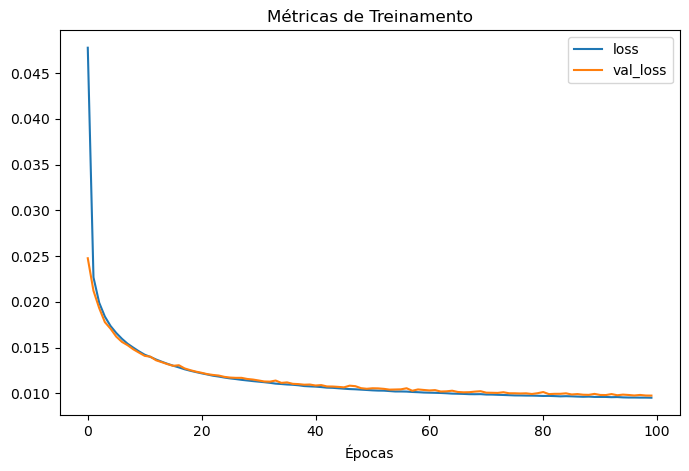

In [16]:
plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.show()

### a) Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


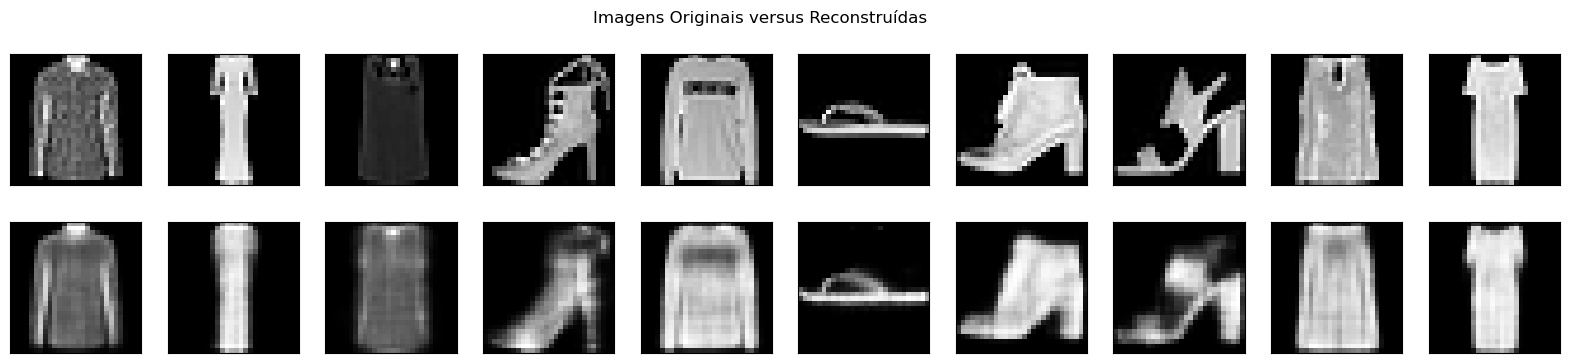

In [17]:
# Generates Reconstructions for the First 10 Images of the Test Set
reconstructed_imgs = autoencoder.predict(x_test_flat[:10])
x_test_unflat = x_test_flat.reshape((len(x_test_flat), 28, 28))

# View Original and Reconstructed Images
n = 10  # Number of Images to Display

plt.figure(figsize=(20, 4))

for i in range(n):
    # Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_unflat[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle("Imagens Originais versus Reconstruídas")
plt.show()

### Item b)

Complete o exercício da questão 4(a) adicionando ruído aleatório às imagens de entrada, com o objetivo de treinar um denoising autoencoder.

Após o treinamento, utilize as 10 imagens selecionadas  na  questão  anterior  (com  o  ruído  aplicado)  e  apresente  os  resultados visualmente, exibindo lado a lado as imagens originais e suas respectivas reconstruções.

Avalie qualitativamente o desempenho do modelo em remover o ruído e preservar as características das imagens originais. 

### b) Data Preprocessing

In [18]:
# Adds Random Noise
noise_factor = 0.7

x_train_noisy = x_train_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train_flat.shape
)
x_val_noisy = x_val_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_val_flat.shape
)
x_test_noisy = x_test_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test_flat.shape
)

# Ensures Values Remain in the Range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_val_noisy = np.clip(x_val_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

### b) Model & Training

In [19]:
# Dimension of the Compressed Representation
encoding_dim = 32

# Input Layer
input_ = keras.layers.Input(shape=(784,))

# Encoder
encoded = keras.layers.Dense(128, activation="relu")(input_)
encoded = keras.layers.Dense(64, activation="relu")(encoded)
encoded = keras.layers.Dense(encoding_dim, activation="relu")(encoded)

# Decoder
decoded = keras.layers.Dense(64, activation="relu")(encoded)
decoded = keras.layers.Dense(128, activation="relu")(decoded)
decoded = keras.layers.Dense(784, activation="sigmoid")(decoded)

# Full Model (Autoencoder)
autoencoder = keras.Model(input_, decoded)
autoencoder.compile(optimizer="adam", loss="mean_squared_error")
autoencoder.summary()

# Train the Model
history = autoencoder.fit(
    x_train_noisy,
    x_train_flat,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(x_val_noisy, x_val_flat),
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0580 - val_loss: 0.0369
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0320 - val_loss: 0.0295
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0282 - val_loss: 0.0280
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0266 - val_loss: 0.0263
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0255 - val_loss: 0.0255
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0248 - val_loss: 0.0249
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0241 - val_loss: 0.0243
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0235 - val_loss: 0.0239
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0231 - val_loss: 0.0239
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0228 - val_loss: 0.0233
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0225 - val_loss: 0.0232
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━━━

### b) Training Metrics

<Figure size 640x480 with 0 Axes>

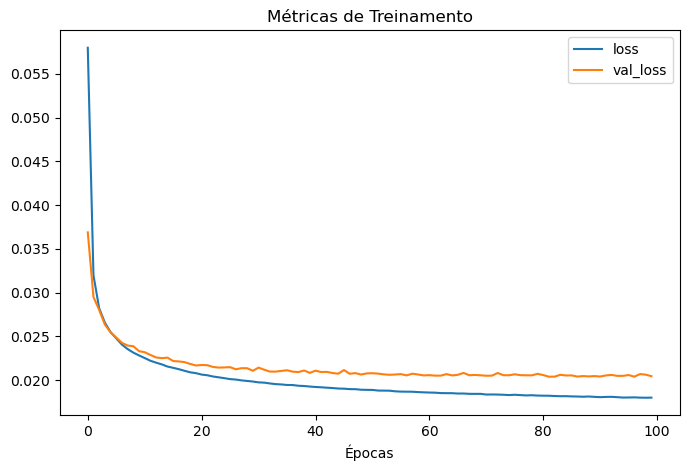

In [20]:
plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.show()

### b) Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


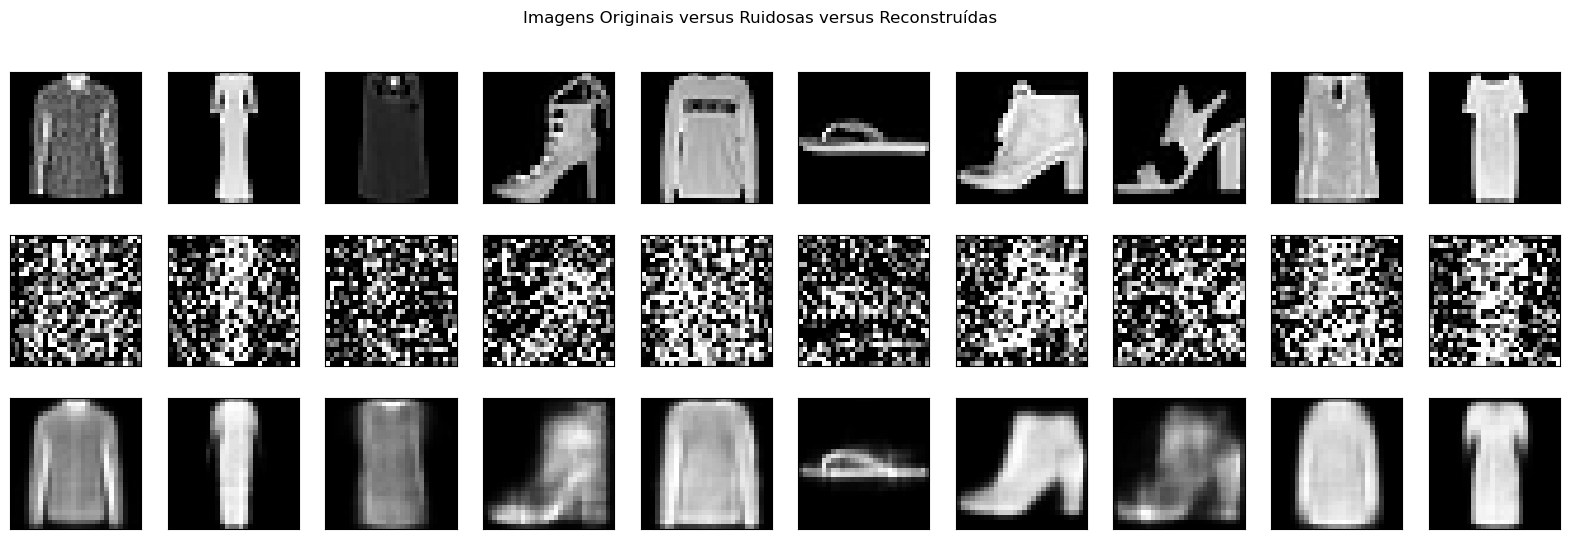

In [21]:
# Generates Reconstructions for the First 10 Images of the Test Set
reconstructed_imgs = autoencoder.predict(x_test_noisy[:10])
x_test_unflat = x_test_flat.reshape((len(x_test_flat), 28, 28))

# View Original and Reconstructed Images
n = 10  # Number of Images to Display

plt.figure(figsize=(20, 6))
for i in range(n):
    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_unflat[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Imagens Originais versus Ruidosas versus Reconstruídas")
plt.show()